In [41]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

In [42]:
df = pd.read_csv(r"C:\Users\hp\Downloads\ML\temperature.csv")

In [43]:
df.head(20)

,Unnamed: 0,Datetime,Hourly_Temp
0,0,04-01-2022 00:00,20.867
1,1,04-01-2022 01:00,21.000
2,2,04-01-2022 02:00,20.867
3,3,04-01-2022 03:00,20.650
4,4,04-01-2022 04:00,20.400
5,5,04-01-2022 05:00,20.100
6,6,04-01-2022 06:00,19.800
7,7,04-01-2022 07:00,19.500
8,8,04-01-2022 08:00,19.400
9,9,04-01-2022 09:00,19.500


In [44]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [45]:
df.head()

,Datetime,Hourly_Temp
0,04-01-2022 00:00,20.867
1,04-01-2022 01:00,21.000
2,04-01-2022 02:00,20.867
3,04-01-2022 03:00,20.650
4,04-01-2022 04:00,20.400


In [46]:
df.shape

(7056, 2)

In [47]:
df.isnull().sum()

Datetime       0
Hourly_Temp    0
dtype: int64

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     7056 non-null   object 
 1   Hourly_Temp  7056 non-null   float64
dtypes: float64(1), object(1)
memory usage: 110.4+ KB


In [49]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%d-%m-%Y %H:%M')
df.set_index('Datetime', inplace=True)
temp_series = df['Hourly_Temp']


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7056 entries, 2022-01-04 00:00:00 to 2022-10-24 23:00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Hourly_Temp  7056 non-null   float64
dtypes: float64(1)
memory usage: 110.2 KB


In [51]:
df.head(5)

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,20.867
2022-01-04 01:00:00,21.000
2022-01-04 02:00:00,20.867
2022-01-04 03:00:00,20.650
2022-01-04 04:00:00,20.400


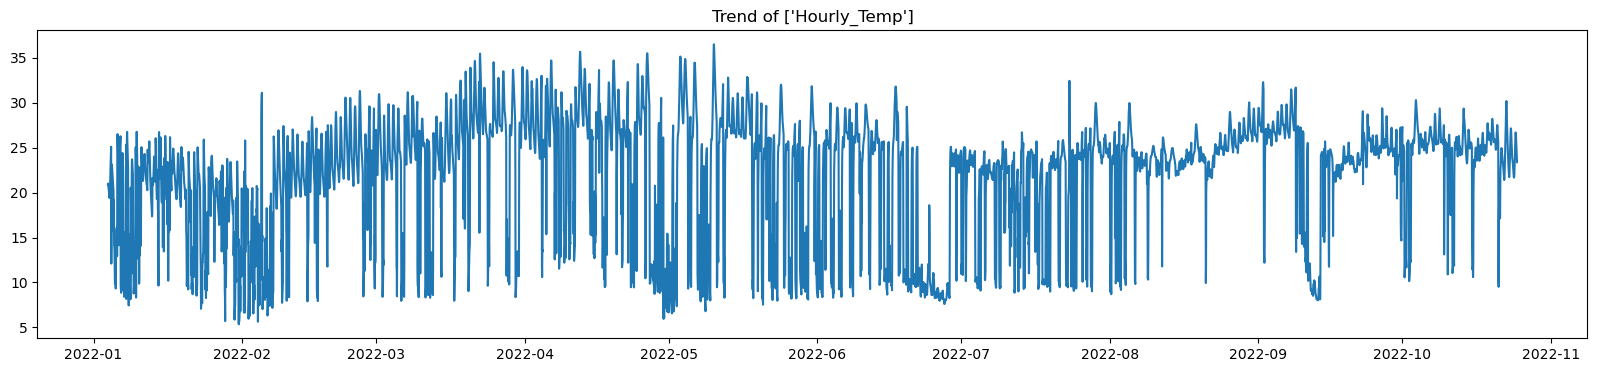

In [52]:
plt.figure(figsize=(20,4))
plt.plot(temp_series)
plt.title(f'Trend of {['Hourly_Temp']}')
plt.show()

In [53]:
train_size = int(len(temp_series) * 0.8)
train_t,test_t = temp_series[:train_size], temp_series[train_size:]
print(f"training points: {len(train_t)}")
print(f"testing points: {len(test_t)}")

training points: 5644
testing points: 1412


In [54]:
model = ARIMA(train_t, order=(1, 1, 1))
results = model.fit()
print("Model Trained")

Model Trained


In [55]:
forecast = results.predict(start=len(train_t), end=len(train_t) + len(test_t) - 1, typ='levels')
rmse = np.sqrt(mean_squared_error(test_t, forecast))
mae = mean_absolute_error(test_t, forecast)
mape = mean_absolute_percentage_error(test_t, forecast)

print(f"RMSE (Average Error Dist): {rmse:.2f}")
print(f"MAE (Average Absolute Error): {mae:.2f}")
print(f"MAPE (Error in Percentage): {mape*100:.2f}%") 

RMSE (Average Error Dist): 5.37
MAE (Average Absolute Error): 3.15
MAPE (Error in Percentage): 21.20%


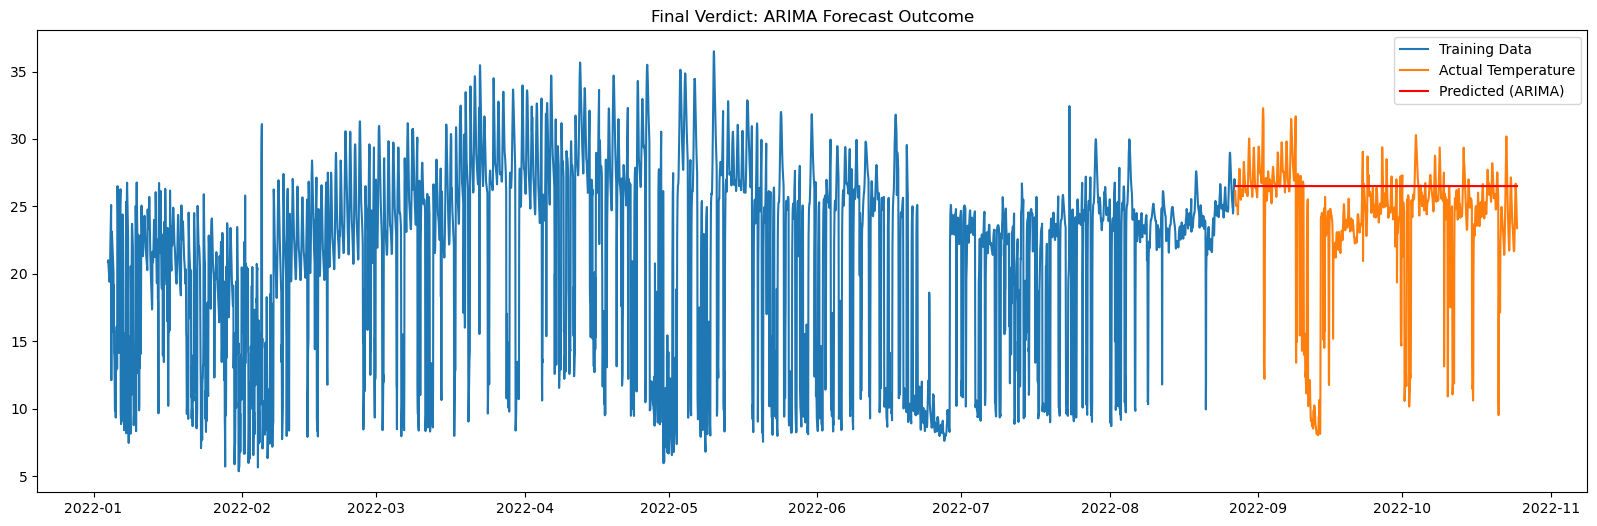

In [56]:
plt.figure(figsize=(20, 6))
plt.plot(train_t, label='Training Data')
plt.plot(test_t, label='Actual Temperature')
plt.plot(forecast, label='Predicted (ARIMA)', color='red')
plt.title('Final Verdict: ARIMA Forecast Outcome')
plt.legend()
plt.show()

In [57]:
df.tail(5)

,Hourly_Temp
Datetime,
2022-10-24 19:00:00,25.567
2022-10-24 20:00:00,25.183
2022-10-24 21:00:00,24.600
2022-10-24 22:00:00,23.986
2022-10-24 23:00:00,23.383


In [59]:
model = ARIMA(temp_series, order=(1,1,1))
results = model.fit()

choice = input("Forecast by (hour/day/week): ").lower()

if choice == "hour":
    n = int(input("How many hours? "))
    steps = n

elif choice == "day":
    n = int(input("How many days? "))
    steps = n * 24

elif choice == "week":
    n = int(input("How many weeks? "))
    steps = n * 24 * 7

else:
    print("Invalid choice")
    steps = None

if steps:
    forecast = results.forecast(steps=steps)
    forecast_df = forecast.to_frame(name="Predicted_Temp")
    print(f"\nTemperature prediction for the next {n} {choice}(s):\n")
    print(forecast_df)




Temperature prediction for the next 2 day(s):

                     Predicted_Temp
2022-10-25 00:00:00       23.328339
2022-10-25 01:00:00       23.330198
2022-10-25 02:00:00       23.330134
2022-10-25 03:00:00       23.330137
2022-10-25 04:00:00       23.330137
2022-10-25 05:00:00       23.330137
2022-10-25 06:00:00       23.330137
2022-10-25 07:00:00       23.330137
2022-10-25 08:00:00       23.330137
2022-10-25 09:00:00       23.330137
2022-10-25 10:00:00       23.330137
2022-10-25 11:00:00       23.330137
2022-10-25 12:00:00       23.330137
2022-10-25 13:00:00       23.330137
2022-10-25 14:00:00       23.330137
2022-10-25 15:00:00       23.330137
2022-10-25 16:00:00       23.330137
2022-10-25 17:00:00       23.330137
2022-10-25 18:00:00       23.330137
2022-10-25 19:00:00       23.330137
2022-10-25 20:00:00       23.330137
2022-10-25 21:00:00       23.330137
2022-10-25 22:00:00       23.330137
2022-10-25 23:00:00       23.330137
2022-10-26 00:00:00       23.330137
2022-10-26 01:00